<a href="https://colab.research.google.com/github/GScaramussa/Redes/blob/main/trabalho4redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Código Original convertido para python

a = 0.02 | tempo de execução: 22.398 s
a = 0.04 | tempo de execução: 20.039 s


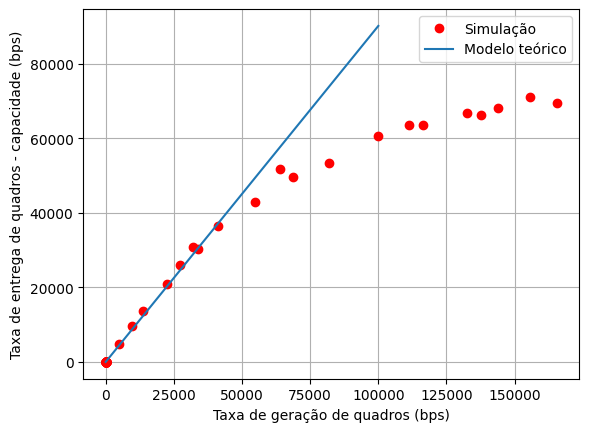

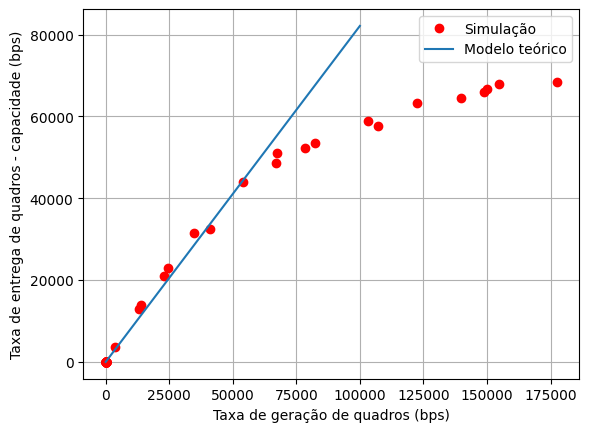

In [2]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt


def simular_csma_cd_1_persistente():
    # PARÂMETROS DE SIMULAÇÃO
    # simulação do protocolo CSMA/CD 1-persistente

    # tempo total da simulação em segundos
    tempo = 0.1

    # número total de estações
    n_est = 10

    # taxa de transmissão do meio em bits por segundo
    taxa_bits = 1e5

    # tamanho do quadro em bits
    tam_quadro = 100

    # tempo de transmissão do quadro em segundos
    t_quadro = tam_quadro / taxa_bits

    # intervalo de tempo da simulação
    dt_sim = t_quadro / tam_quadro

    # tempo total da simulação em instantes
    t_sim = math.ceil(tempo / dt_sim)

    # taxa média máxima de chegada de quadros por segundo para cada estação
    taxa_max_quadro = math.ceil(taxa_bits / tam_quadro / n_est)

    # variação da taxa de geração de quadros
    pontos = 20
    taxas_quadro = taxa_max_quadro * np.arange(1 / pontos, 1 + 1 / pontos, 1 / pontos)

    fig = 1

    for a in [0.02, 0.04]:
        # resultados da simulação
        quadros_entregues = np.zeros(taxa_max_quadro)
        quadros_gerados = np.zeros(taxa_max_quadro)
        quadros_colididos = np.zeros(taxa_max_quadro)
        quadros_bloqueados = np.zeros(taxa_max_quadro)

        inicio = time.time()

        for taxa in range(pontos):
            taxa_quadro = taxas_quadro[taxa]

            # taxa média de chegada de quadros por instante de simulação
            tm_q = taxa_quadro * dt_sim

            # janela de tempo de espera aleatório em número de instantes de simulação
            espera_max = 10 * tam_quadro

            # número de repetições da simulação - para tirar a média
            rodadas = 5

            for _ in range(rodadas):
                # VARIÁVEIS DOS EVENTOS
                # transmissores ativos
                tx_ativo = np.zeros(n_est, dtype=int)

                # fila de quadros do transmissor
                tx_fila = np.zeros(n_est, dtype=int)

                # contador de progresso do transmissor
                tx_cnt = np.zeros(n_est, dtype=int)

                # armazenador de colisões
                colis = np.zeros(t_sim, dtype=int)

                # índices das estações com colisão
                colin = np.zeros(n_est, dtype=int)

                # espera aleatória em caso de colisão
                tx_espera = np.zeros(n_est, dtype=int)

                # armazenador das transmissões
                transmis = np.zeros((n_est, t_sim), dtype=int)

                # armazenador da chegada dos quadros
                chegada_quadros = 0

                # armazenador de quadros colididos
                colisoes = 0

                # armazenador de quadros entregues
                entregues = 0

                # armazenador de bloqueios
                bloqueios = 0  # backoffs

                # guarda o estado do meio (com atraso)
                tx_ativo_atr = np.zeros(n_est, dtype=int)

                # atraso de propagação
                atraso = math.ceil(a * tam_quadro / taxa_bits / dt_sim)

                for k in range(t_sim):
                    # guarda o estado do meio (com atraso!)
                    if k >= atraso:
                        tx_ativo_atr = transmis[:, k - atraso].copy()
                    else:
                        tx_ativo_atr = np.zeros(n_est, dtype=int)

                    for j in range(n_est):
                        # verificar se o transmissor está ativo
                        if tx_ativo[j] == 1:
                            transmis[j, k] = 1

                        # verificar se o quadro foi enviado
                        if tx_cnt[j] > 0:
                            # verificar se a transmissão sofreu colisão
                            if colin[j] == 1:
                                tx_cnt[j] = 0  # aborta transmissão
                                tx_ativo[j] = 0
                                # aguarda um tempo aleatório
                                tx_espera[j] = math.ceil(espera_max * np.random.rand())
                                tx_fila[j] += 1
                                colin[j] = 0
                                colisoes += 1
                            else:
                                tx_cnt[j] -= 1
                                if tx_cnt[j] == 0:
                                    tx_ativo[j] = 0
                                    entregues += 1

                        else:
                            # verificar se tem quadros em espera e se o meio está livre
                            if tx_fila[j] > 0:
                                if tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) == 0:
                                    tx_ativo[j] = 1
                                    tx_cnt[j] = math.ceil(tam_quadro / taxa_bits / dt_sim)
                                    tx_fila[j] -= 1
                                elif tx_espera[j] > 0:
                                    # decrementar o contador do tempo de espera
                                    tx_espera[j] -= 1
                                elif np.count_nonzero(tx_ativo_atr) > 0:
                                    # meio está ocupado - modo 1-persistente
                                    tx_espera[j] = 2 * atraso  # aguarda o tempo de 1 mini-slot
                                    bloqueios += 1

                        # verificar se chegou um novo quadro
                        p_novo = np.random.rand()
                        if p_novo < tm_q:
                            chegada_quadros += 1

                            # verificar se o transmissor está pronto
                            if tx_ativo[j] == 0 and tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) == 0:
                                tx_ativo[j] = 1
                                tx_cnt[j] = math.ceil(tam_quadro / taxa_bits / dt_sim)
                            else:
                                tx_fila[j] += 1
                                if tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) > 0:
                                    # meio ocupado
                                    tx_espera[j] = 2 * atraso  # aguarda o tempo de 1 mini-slot
                                    bloqueios += 1

                    # verifica se houve colisão
                    if np.count_nonzero(tx_ativo) > 1:
                        colis[k] = 1
                        colin = np.logical_or(colin, tx_ativo).astype(int)

                quadros_entregues[taxa] += entregues / rodadas
                quadros_gerados[taxa] += chegada_quadros / rodadas
                quadros_colididos[taxa] += colisoes / rodadas
                quadros_bloqueados[taxa] += bloqueios / rodadas

        fim = time.time()
        print(f"a = {a:.2f} | tempo de execução: {fim - inicio:.3f} s")

        # CSMA/CD 1-persistente
        U = 1 / (1 + 2 * a * math.e)
        G = np.arange(0, 1.01, 0.01)
        S = U * G

        plt.figure(fig)
        fig += 1
        plt.plot(
            (quadros_colididos + quadros_entregues) * tam_quadro / tempo,
            quadros_entregues * tam_quadro / tempo,
            'ro',
            label='Simulação'
        )
        plt.plot(G * taxa_bits, S * taxa_bits, '-', label='Modelo teórico')
        plt.grid(True)
        plt.xlabel('Taxa de geração de quadros (bps)')
        plt.ylabel('Taxa de entrega de quadros - capacidade (bps)')
        plt.legend()

    plt.show()


if __name__ == "__main__":
    simular_csma_cd_1_persistente()

## Fluxograma da simulação do protocolo CSMA/CD

```text
Início
  ↓
Definir parâmetros da simulação
(tempo, número de estações, taxa de bits, tamanho do quadro,
intervalo de simulação, atraso de propagação, número de rodadas)
  ↓
Para cada valor de atraso de propagação "a"
  ↓
Para cada taxa de geração de quadros
  ↓
Inicializar variáveis da rodada
(filas, transmissores ativos, contadores, colisões, entregues, bloqueios)
  ↓
Para cada rodada da simulação
  ↓
Para cada instante de tempo k
  ↓
Atualizar estado do meio com atraso de propagação
  ↓
Para cada estação j
  ↓
A estação está transmitindo?
 ├── Sim:
 │     ↓
 │   Registrar transmissão
 │     ↓
 │   Houve colisão?
 │    ├── Sim:
 │    │     Aborta transmissão
 │    │     Gera espera aleatória
 │    │     Recoloca quadro na fila
 │    │     Soma colisão
 │    │
 │    └── Não:
 │          Continua transmitindo
 │          Se terminar, soma entrega
 │
 └── Não:
       ↓
     Há quadro na fila?
      ├── Sim:
      │    ↓
      │  Meio livre e sem espera?
      │   ├── Sim: inicia transmissão
      │   ├── Não, ainda em espera: decrementa contador
      │   └── Não, meio ocupado: espera mini-slot e soma bloqueio
      │
      └── Não:
            segue
  ↓
Gerar possível novo quadro aleatoriamente
  ↓
Chegou quadro novo?
 ├── Sim:
 │    ↓
 │  Meio livre?
 │   ├── Sim: transmite imediatamente
 │   └── Não: coloca na fila e espera
 │
 └── Não:
      segue
  ↓
Verificar se mais de uma estação transmitiu ao mesmo tempo
 ├── Sim: registrar colisão
 └── Não: segue
  ↓
Fim do instante k
  ↓
Fim da rodada
  ↓
Calcular médias dos resultados
(quadros gerados, entregues, colididos e bloqueados)
  ↓
Comparar com o modelo teórico
  ↓
Plotar gráficos
  ↓
Fim

## Funcionamento da simulação do CSMA/CD

A simulação começa com a definição dos parâmetros principais da rede, como tempo total, número de estações, taxa de transmissão, tamanho do quadro e atraso de propagação. Depois, para cada taxa de geração de quadros e para cada rodada, o programa inicializa as variáveis de controle das estações, das filas e das transmissões.
Em cada instante de tempo, cada estação pode gerar um novo quadro aleatoriamente. Se o meio estiver livre, a estação transmite; se estiver ocupado, o quadro entra na fila. Quando duas ou mais estações transmitem ao mesmo tempo, ocorre colisão. Nesse caso, a transmissão é interrompida, o quadro volta para a fila e a estação espera um tempo aleatório antes de tentar novamente. Ao final, a simulação calcula a quantidade de quadros gerados, entregues, colididos e bloqueados, e compara os resultados com o modelo teórico.

## Diferenças em relação à situação real

A simulação é uma versão simplificada da rede real. O tempo é tratado em passos discretos, enquanto no mundo real os eventos acontecem de forma contínua. Além disso, a geração de quadros é feita de forma aleatória e simplificada, sem representar toda a variação do tráfego real.

Outro ponto é que o código não considera vários fatores físicos do Ethernet real, como ruídos, falhas de hardware e outros atrasos do sistema. Assim, a simulação serve para analisar o comportamento geral do protocolo e comparar com a teoria, mas não reproduz exatamente uma rede real.

In [7]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
def simulate_csma_cd(
    tempo=0.1,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    a_values=(0.02, 0.04),
    pontos=20,
    rodadas=5,
    espera_max_factor=10,
    seed=42
):
    rng = random.Random(seed)

    t_quadro = tam_quadro / taxa_bits
    dt_sim = t_quadro / tam_quadro
    t_sim = math.ceil(tempo / dt_sim)

    taxa_max_quadro = math.ceil(taxa_bits / tam_quadro / n_est)
    taxas_quadro = taxa_max_quadro * (np.arange(1, pontos + 1) / pontos)

    results = {}

    for a in a_values:
        quadros_entregues = np.zeros(pontos)
        quadros_gerados = np.zeros(pontos)
        quadros_colididos = np.zeros(pontos)
        quadros_bloqueados = np.zeros(pontos)

        for taxa_idx, taxa_quadro in enumerate(taxas_quadro):
            tm_q = taxa_quadro * dt_sim
            espera_max = int(espera_max_factor * tam_quadro)

            for _ in range(rodadas):
                tx_ativo = [0] * n_est
                tx_fila = [0] * n_est
                tx_cnt = [0] * n_est
                colin = [0] * n_est
                tx_espera = [0] * n_est

                transmis = np.zeros((n_est, t_sim), dtype=int)

                chegada_quadros = 0
                colisoes = 0
                entregues = 0
                bloqueios = 0

                atraso = math.ceil(a * tam_quadro / taxa_bits / dt_sim)
                tx_len = math.ceil(tam_quadro / taxa_bits / dt_sim)

                for k in range(t_sim):
                    if k > atraso:
                        tx_ativo_atr = transmis[:, k - atraso]
                    else:
                        tx_ativo_atr = np.zeros(n_est, dtype=int)

                    for j in range(n_est):
                        if tx_ativo[j] == 1:
                            transmis[j, k] = 1

                        if tx_cnt[j] > 0:
                            if colin[j] == 1:
                                tx_cnt[j] = 0
                                tx_ativo[j] = 0
                                tx_espera[j] = math.ceil(espera_max * rng.random())
                                tx_fila[j] += 1
                                colin[j] = 0
                                colisoes += 1
                            else:
                                tx_cnt[j] -= 1
                                if tx_cnt[j] == 0:
                                    tx_ativo[j] = 0
                                    entregues += 1
                        else:
                            if tx_fila[j] > 0:
                                if tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) == 0:
                                    tx_ativo[j] = 1
                                    tx_cnt[j] = tx_len
                                    tx_fila[j] -= 1
                                elif tx_espera[j] > 0:
                                    tx_espera[j] -= 1
                                elif np.count_nonzero(tx_ativo_atr) > 0:
                                    tx_espera[j] = 2 * atraso
                                    bloqueios += 1

                        if rng.random() < tm_q:
                            chegada_quadros += 1
                            if tx_ativo[j] == 0 and tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) == 0:
                                tx_ativo[j] = 1
                                tx_cnt[j] = tx_len
                            else:
                                tx_fila[j] += 1
                                if tx_espera[j] == 0 and np.count_nonzero(tx_ativo_atr) > 0:
                                    tx_espera[j] = 2 * atraso
                                    bloqueios += 1

                    if sum(tx_ativo) > 1:
                        for j in range(n_est):
                            if tx_ativo[j]:
                                colin[j] = 1

                quadros_entregues[taxa_idx] += entregues / rodadas
                quadros_gerados[taxa_idx] += chegada_quadros / rodadas
                quadros_colididos[taxa_idx] += colisoes / rodadas
                quadros_bloqueados[taxa_idx] += bloqueios / rodadas

        U = 1 / (1 + 2 * a * math.e)
        G = np.arange(0, 1.01, 0.01)
        S = U * G

        results[a] = {
            "taxas_quadro": taxas_quadro,
            "entregues": quadros_entregues,
            "gerados": quadros_gerados,
            "colididos": quadros_colididos,
            "bloqueados": quadros_bloqueados,
            "x_bps": (quadros_colididos + quadros_entregues) * tam_quadro / tempo,
            "y_bps": quadros_entregues * tam_quadro / tempo,
            "theory_x": G * taxa_bits,
            "theory_y": S * taxa_bits
        }

    return results


In [8]:
def plot_results(results, titulo_extra=""):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, (a, data) in zip(axes, results.items()):
        ax.plot(data["x_bps"], data["y_bps"], 'o', label='Simulação')
        ax.plot(data["theory_x"], data["theory_y"], '-', label='Modelo teórico')
        ax.set_title(f"a = {a} {titulo_extra}")
        ax.set_xlabel("Taxa de geração de quadros (bps)")
        ax.set_ylabel("Taxa de entrega / capacidade (bps)")
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

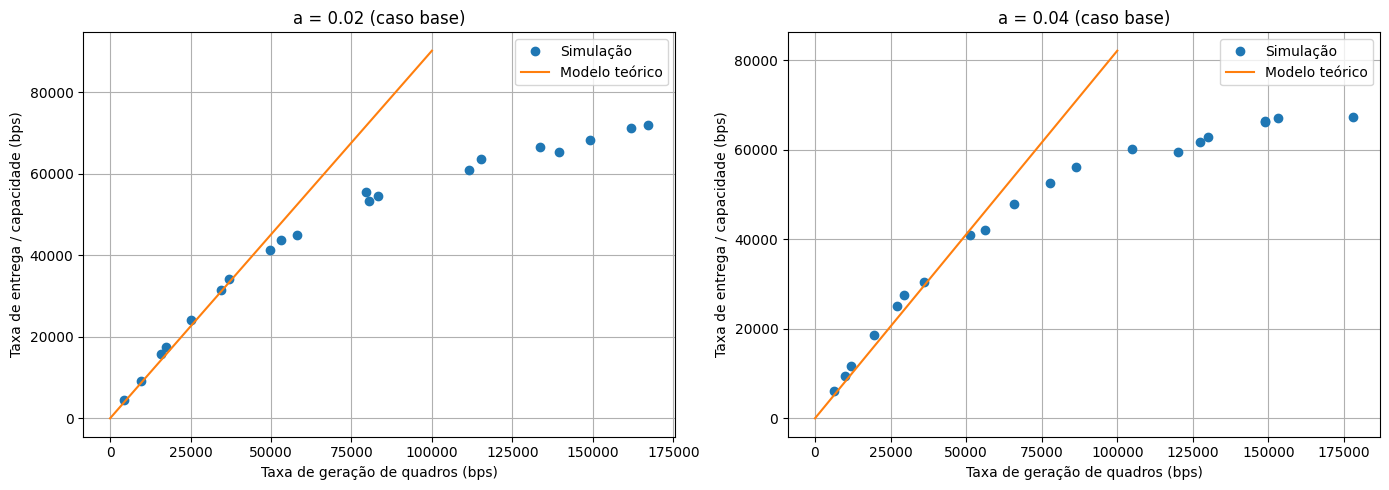

In [9]:
base_results = simulate_csma_cd(
    tempo=0.1,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    a_values=(0.02, 0.04),
    pontos=20,
    rodadas=5,
    seed=42
)

plot_results(base_results, "(caso base)")

### a) Tempo de simulação

O aumento do tempo de simulação reduz a influência de flutuações aleatórias e torna os resultados experimentais mais estáveis. Com tempos muito curtos, a curva simulada tende a apresentar maior dispersão em relação ao modelo teórico, pois há menos eventos observados e o efeito estatístico de colisões e transmissões individuais se torna mais forte. Já com tempos maiores, a simulação converge melhor para o comportamento médio previsto teoricamente. Assim, o principal efeito do aumento do tempo de simulação não é alterar a tendência física do sistema, mas melhorar a confiabilidade da estimativa obtida.

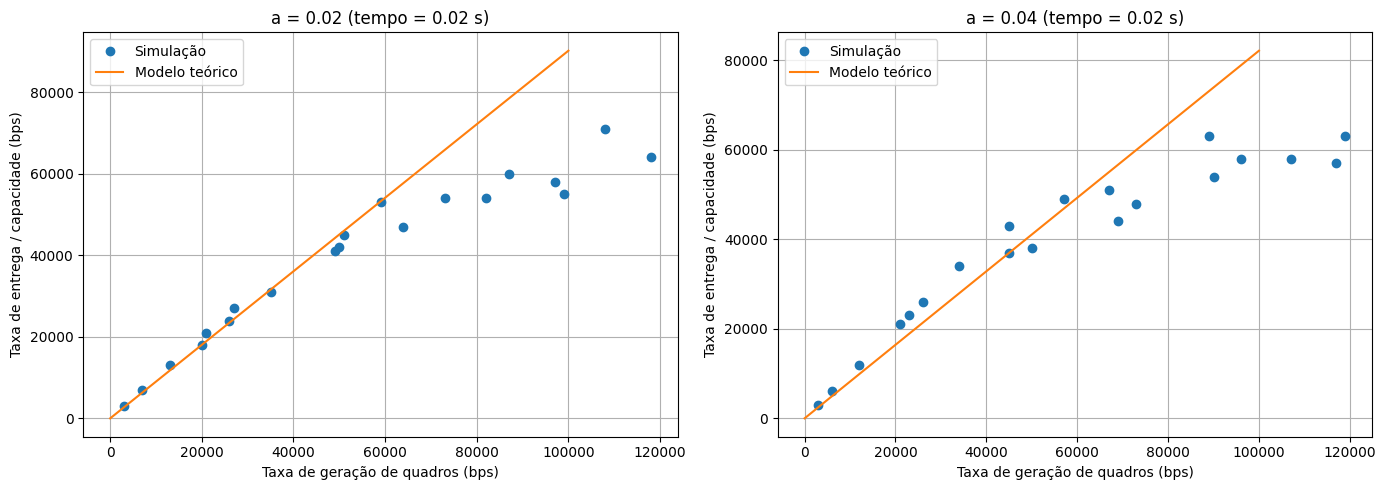

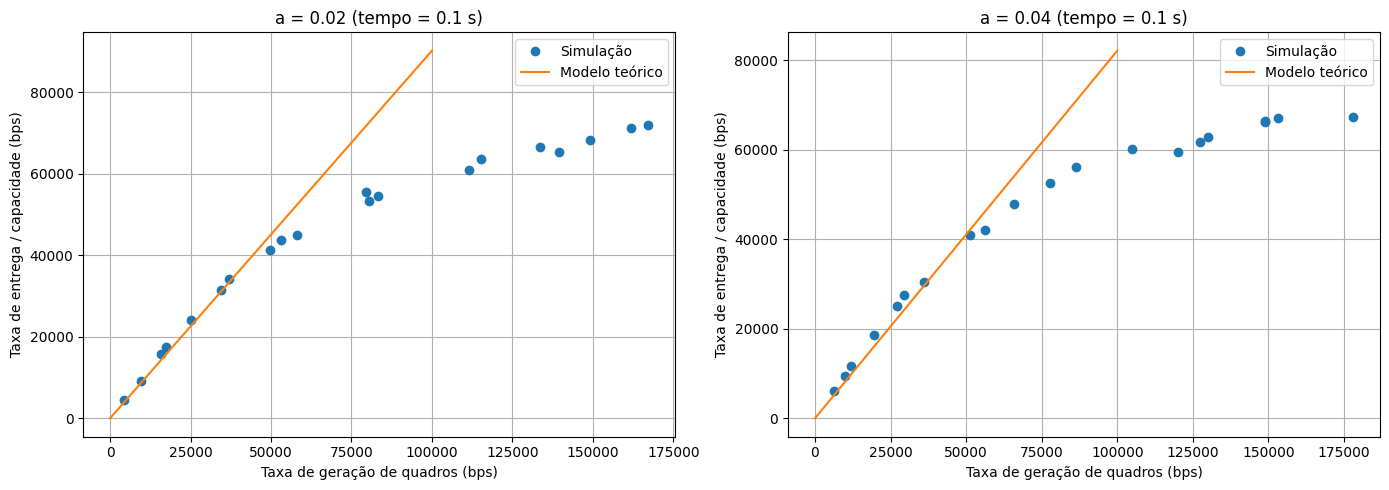

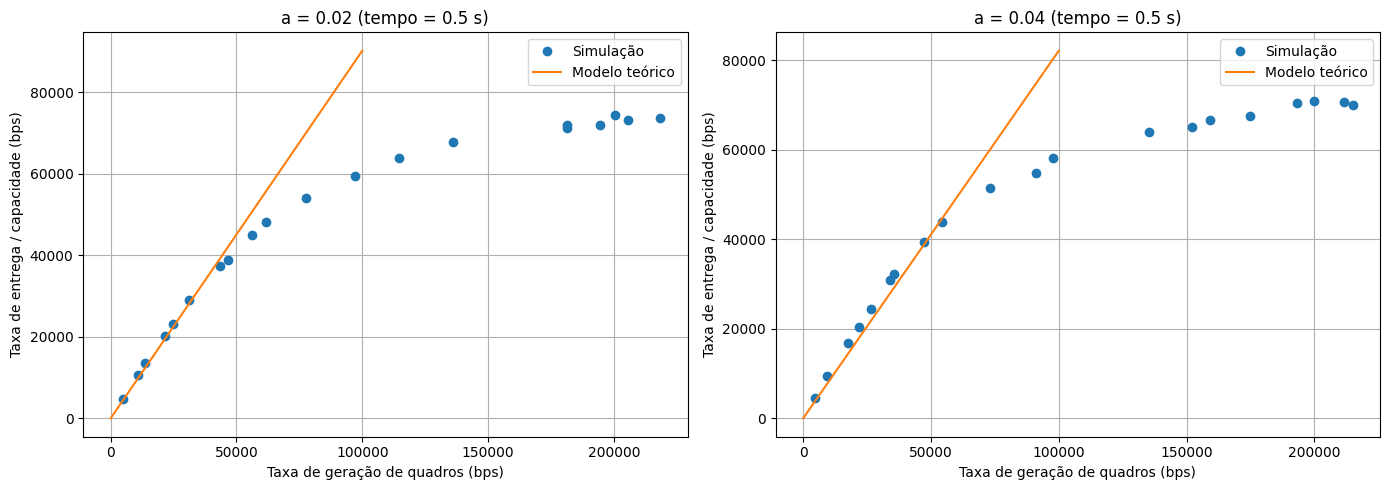

In [10]:
tempos = [0.02, 0.1, 0.5]

for tempo in tempos:
    results = simulate_csma_cd(
        tempo=tempo,
        n_est=10,
        taxa_bits=1e5,
        tam_quadro=100,
        a_values=(0.02, 0.04),
        pontos=20,
        rodadas=5,
        seed=42
    )
    plot_results(results, f"(tempo = {tempo} s)")

### b) Número de estações

O aumento do número de estações eleva a competição pelo meio compartilhado. Com mais estações tentando transmitir, cresce a probabilidade de acessos simultâneos e, portanto, de colisões e bloqueios. Na prática, isso faz a curva simulada tender a saturar mais rapidamente. O modelo teórico representa a eficiência média do protocolo, mas a simulação evidencia de forma mais visível o impacto da disputa entre várias estações. Portanto, quanto maior o número de estações, maior a contenção do meio e maior a diferença prática observada em regiões de carga elevada.

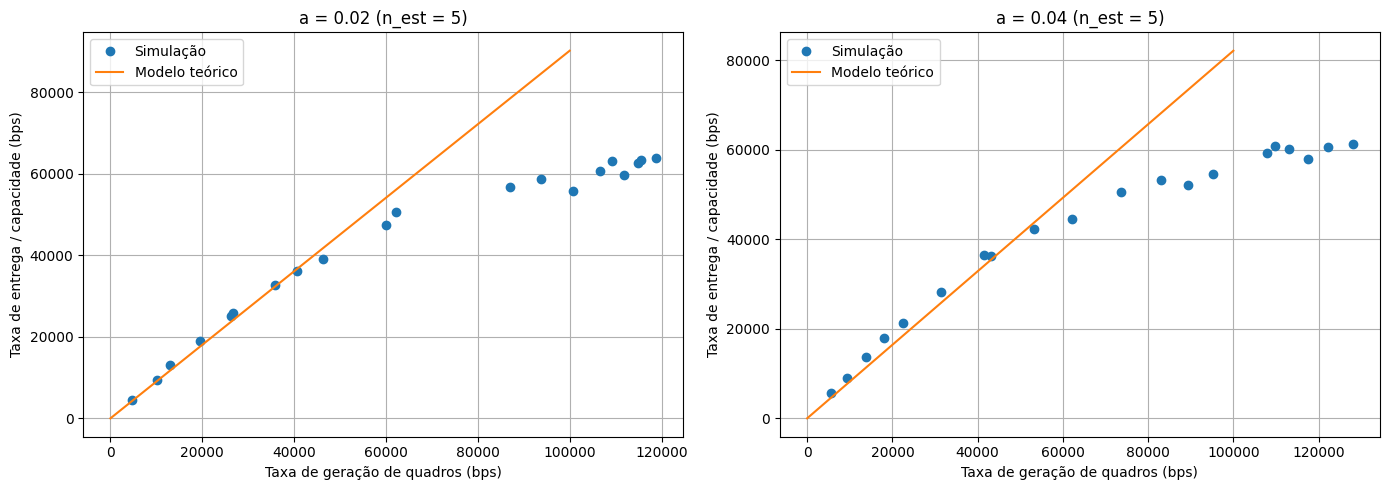

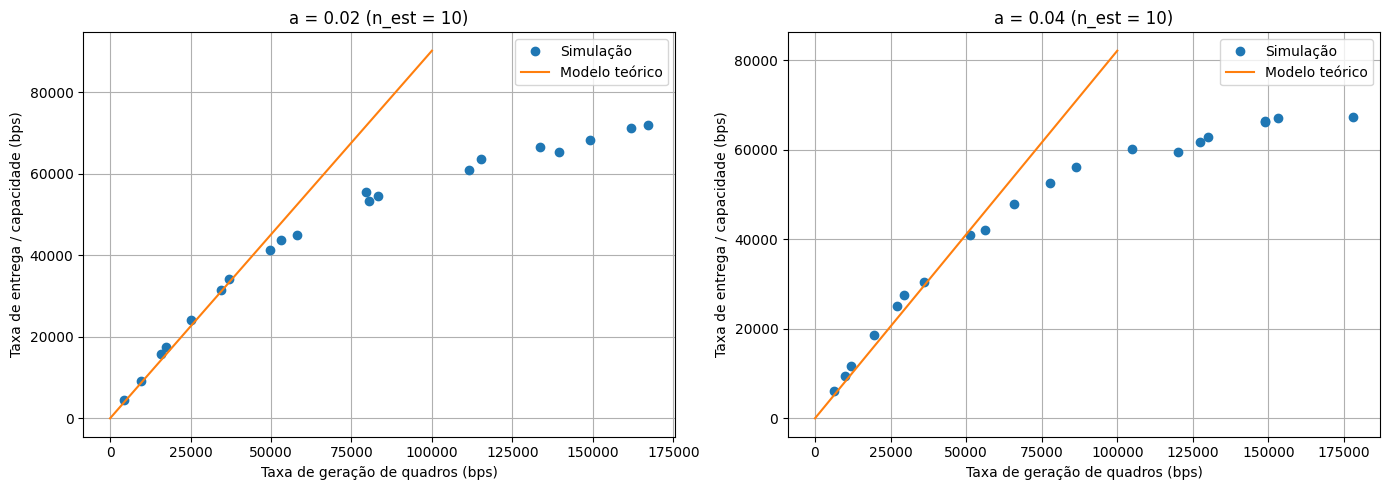

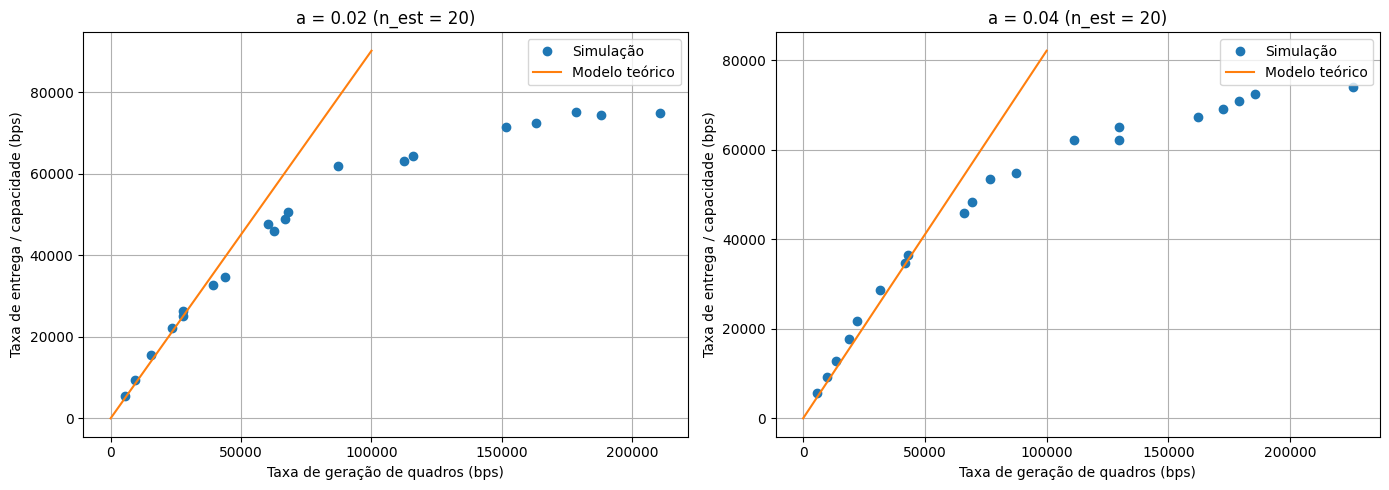

In [11]:
num_estacoes = [5, 10, 20]

for n_est in num_estacoes:
    results = simulate_csma_cd(
        tempo=0.1,
        n_est=n_est,
        taxa_bits=1e5,
        tam_quadro=100,
        a_values=(0.02, 0.04),
        pontos=20,
        rodadas=5,
        seed=42
    )
    plot_results(results, f"(n_est = {n_est})")

### c) Taxa de transmissão (bps)

A taxa de transmissão altera a escala em bits por segundo dos resultados. Quando a taxa de bits aumenta, a capacidade máxima do meio também aumenta, deslocando a curva para valores mais altos de throughput. No entanto, a tendência geral do protocolo permanece semelhante, porque o modelo teórico depende principalmente da relação entre o atraso de propagação e o tempo de transmissão do quadro. Assim, a variação da taxa de transmissão modifica principalmente a escala do gráfico, e não a forma básica do comportamento.

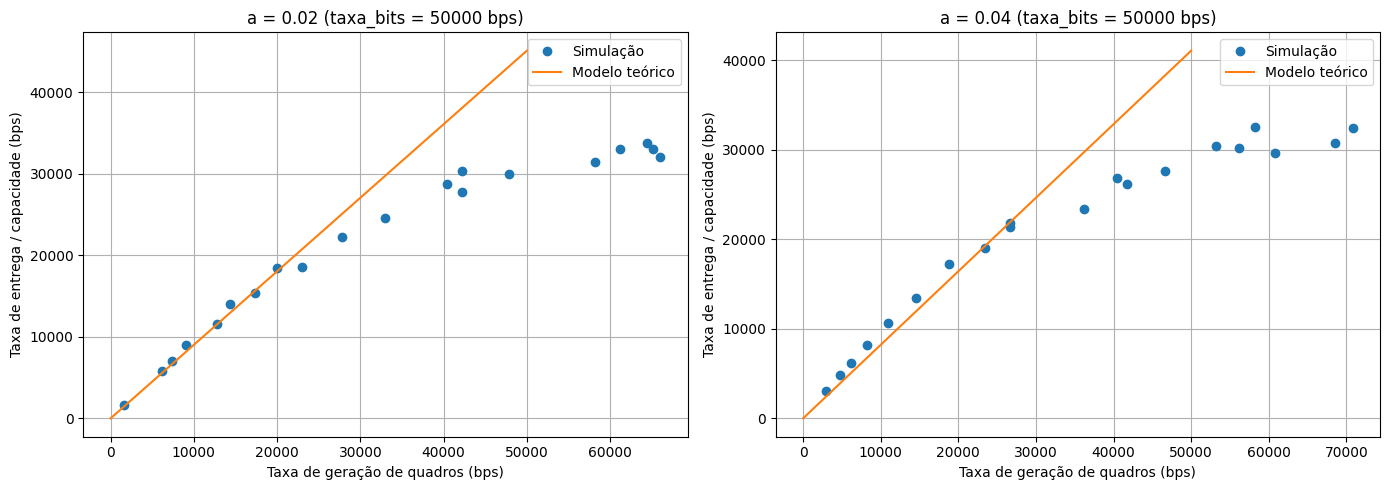

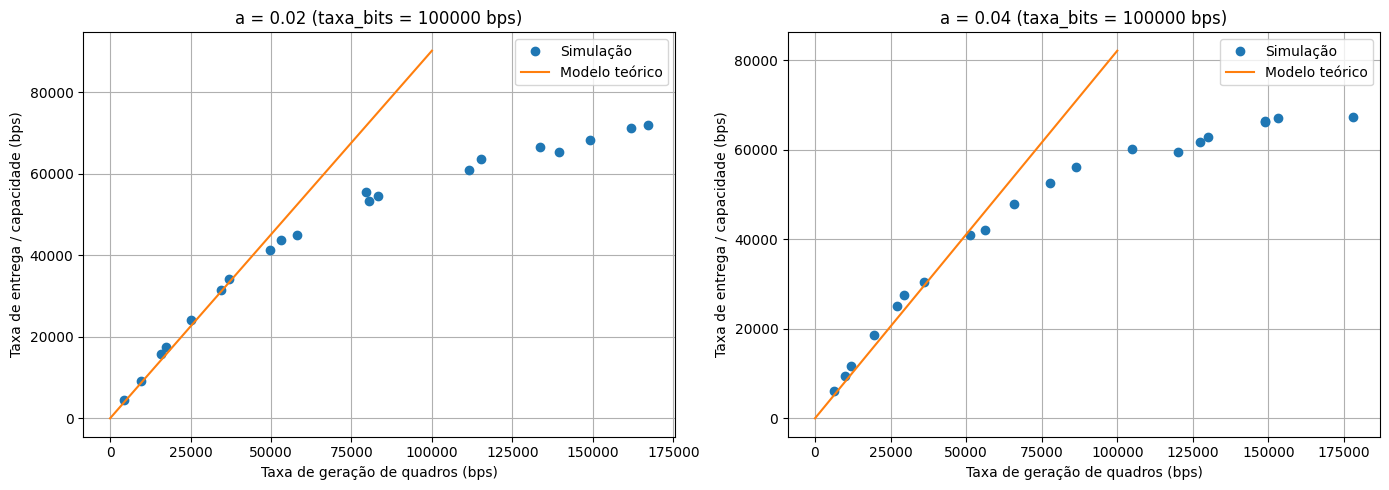

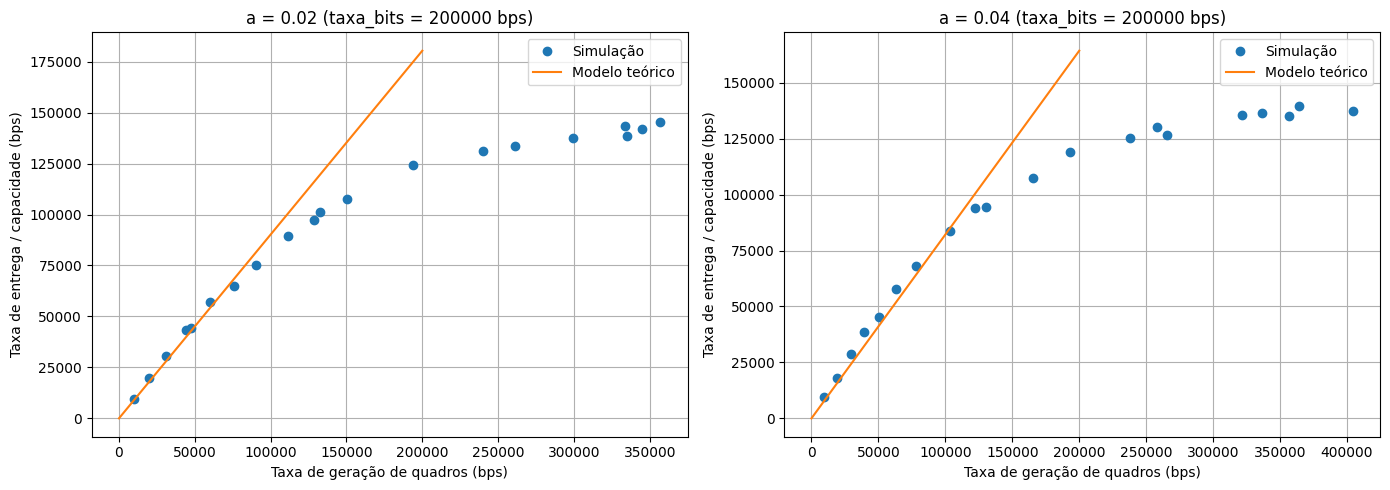

In [12]:
taxas_bits = [5e4, 1e5, 2e5]

for taxa_bits in taxas_bits:
    results = simulate_csma_cd(
        tempo=0.1,
        n_est=10,
        taxa_bits=taxa_bits,
        tam_quadro=100,
        a_values=(0.02, 0.04),
        pontos=20,
        rodadas=5,
        seed=42
    )
    plot_results(results, f"(taxa_bits = {int(taxa_bits)} bps)")

### d) Tamanho do quadro

O tamanho do quadro influencia diretamente o tempo de transmissão. Quadros maiores permanecem mais tempo ocupando o meio e, por isso, reduzem proporcionalmente o impacto do atraso de propagação. Isso tende a melhorar a eficiência do protocolo, aproximando a simulação do modelo teórico com maior capacidade útil. Já quadros menores tornam a transmissão mais sensível ao atraso relativo de propagação, aumentando o peso das colisões e reduzindo a eficiência. Assim, quadros maiores tendem a produzir melhor aproveitamento do meio.

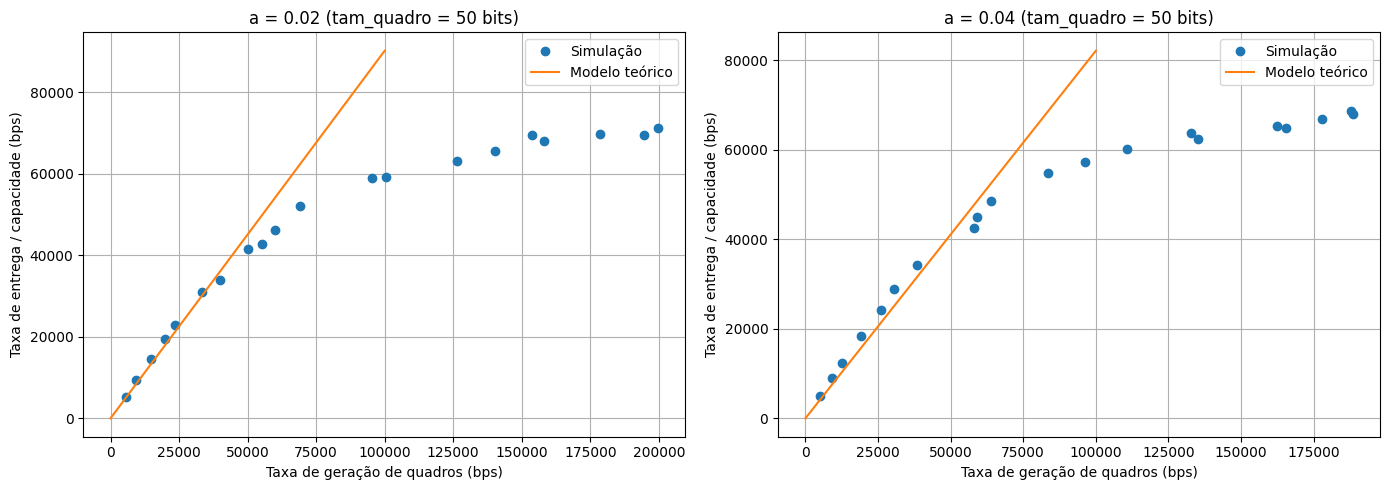

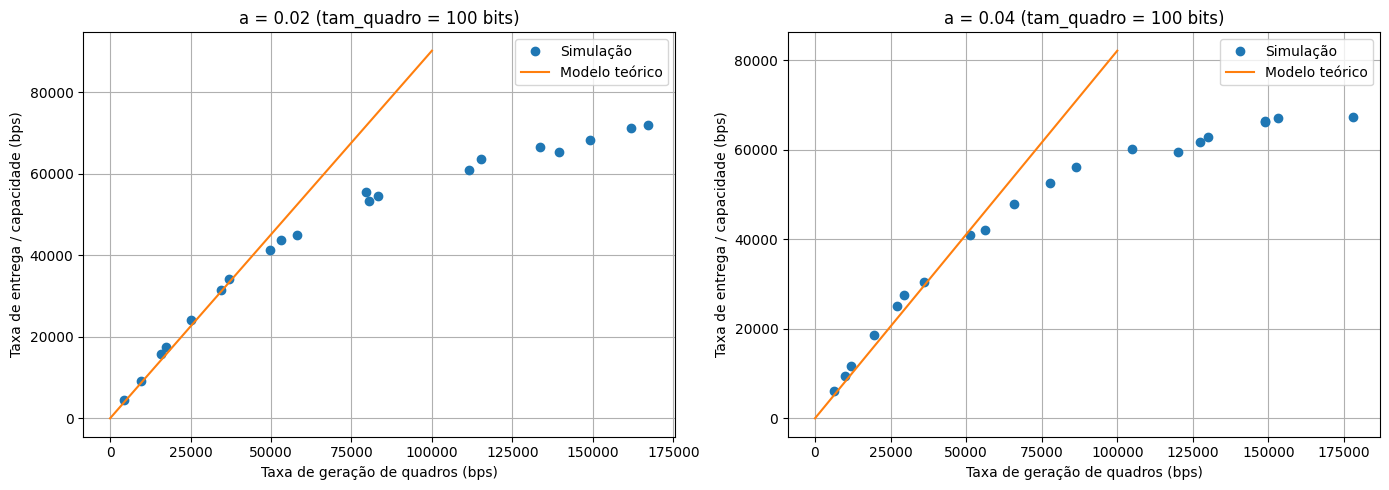

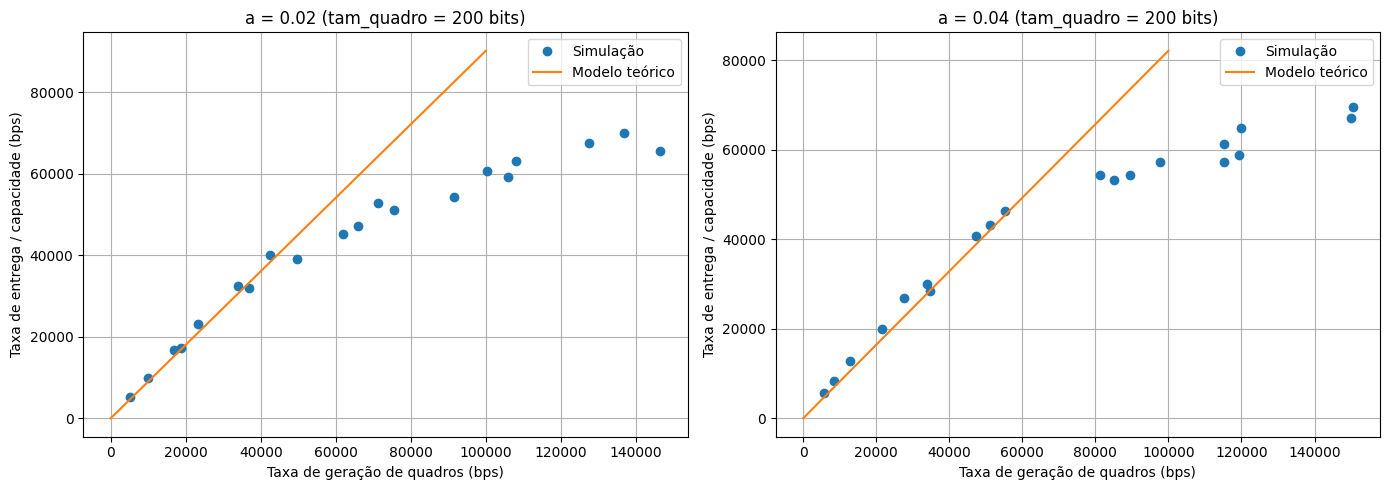

In [13]:
tamanhos_quadro = [50, 100, 200]

for tam_quadro in tamanhos_quadro:
    results = simulate_csma_cd(
        tempo=0.1,
        n_est=10,
        taxa_bits=1e5,
        tam_quadro=tam_quadro,
        a_values=(0.02, 0.04),
        pontos=20,
        rodadas=5,
        seed=42
    )
    plot_results(results, f"(tam_quadro = {tam_quadro} bits)")

### e) Número de rodadas de simulação

O número de rodadas afeta a qualidade estatística dos resultados. Com poucas rodadas, a curva simulada pode ficar mais irregular, pois depende fortemente do comportamento aleatório de cada execução. Quando o número de rodadas aumenta, a média calculada se torna mais representativa e a curva obtida tende a ficar mais suave e mais próxima da previsão teórica. Portanto, o aumento do número de rodadas não altera o funcionamento do protocolo, mas melhora a precisão experimental da comparação com o modelo.

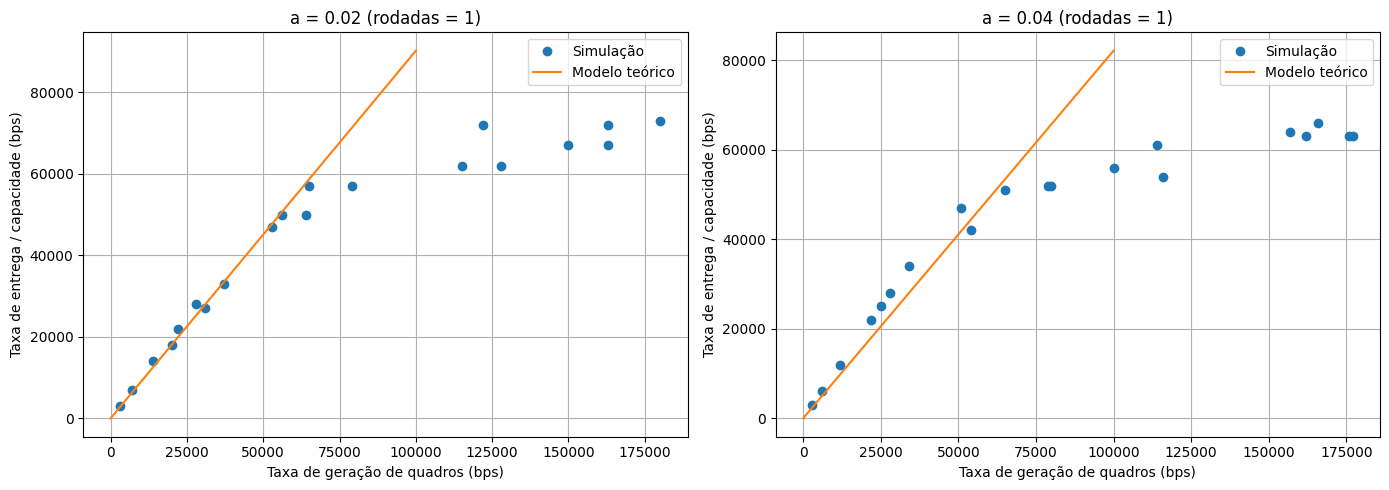

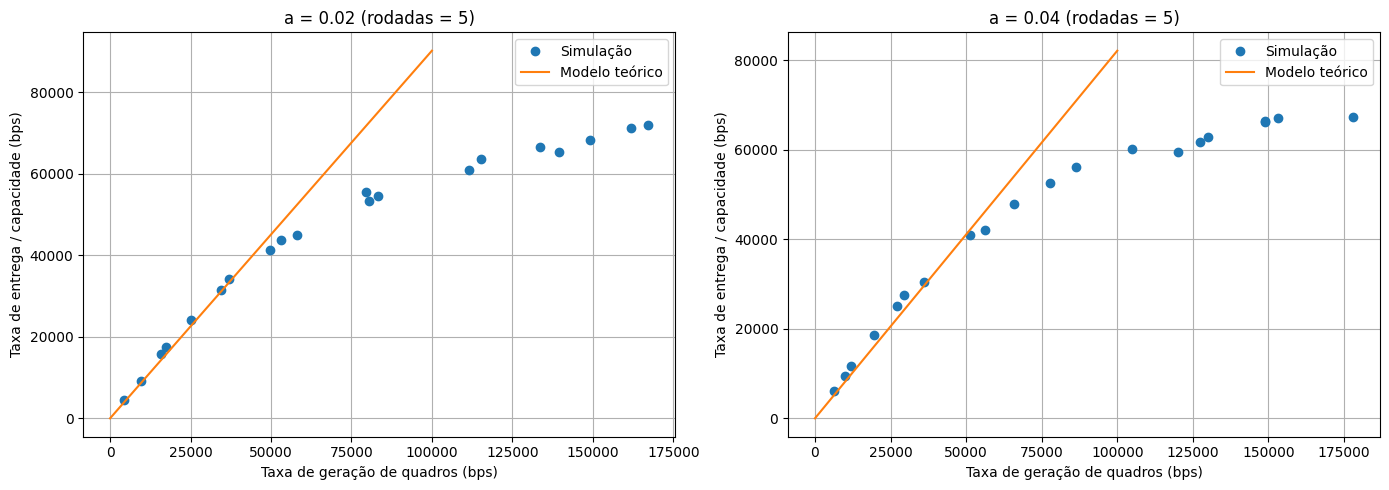

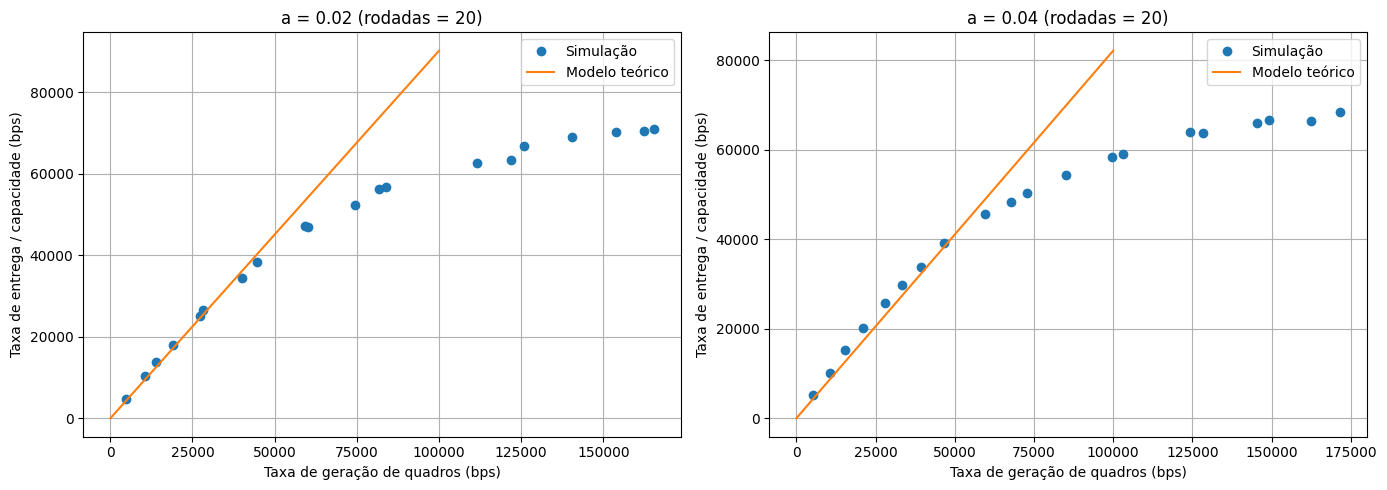

In [14]:
rodadas_lista = [1, 5, 20]

for rodadas in rodadas_lista:
    results = simulate_csma_cd(
        tempo=0.1,
        n_est=10,
        taxa_bits=1e5,
        tam_quadro=100,
        a_values=(0.02, 0.04),
        pontos=20,
        rodadas=rodadas,
        seed=42
    )
    plot_results(results, f"(rodadas = {rodadas})")

### f) Relação entre atraso de propagação e tempo de transmissão de um quadro

Esse é um dos parâmetros mais importantes da análise. Quando a razão a aumenta, o atraso de propagação se torna mais relevante em comparação com o tempo necessário para transmitir um quadro inteiro. Isso faz com que mais estações possam iniciar transmissões quase ao mesmo tempo sem perceber imediatamente a ocupação do meio, aumentando as colisões e reduzindo a eficiência. Por isso, tanto o modelo teórico quanto a simulação mostram pior desempenho para valores maiores de a. Quanto menor essa razão, mais eficiente tende a ser o protocolo CSMA/CD.

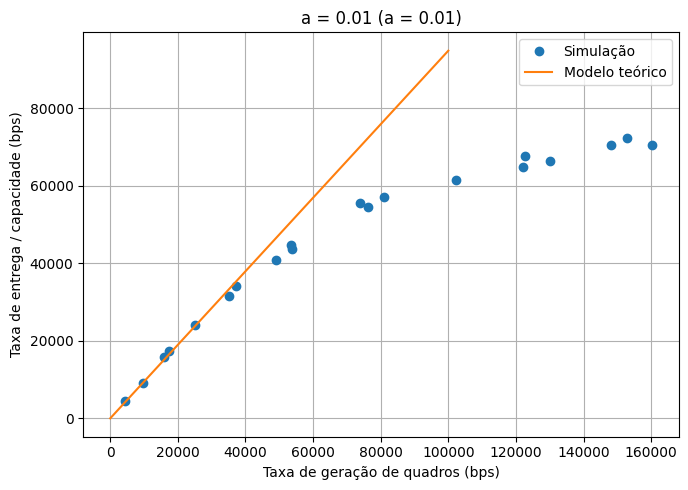

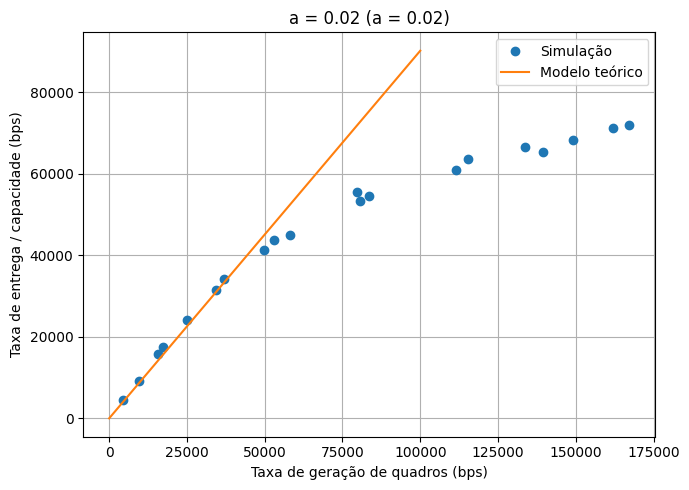

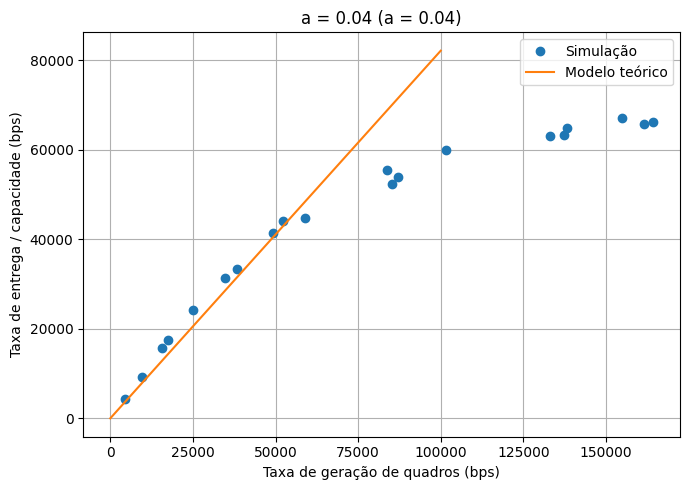

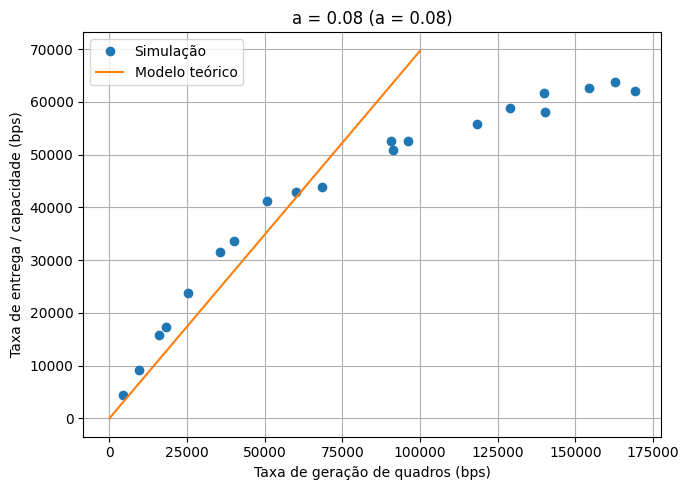

In [15]:
a_values_sets = [
    (0.01,),
    (0.02,),
    (0.04,),
    (0.08,)
]

for a_vals in a_values_sets:
    results = simulate_csma_cd(
        tempo=0.1,
        n_est=10,
        taxa_bits=1e5,
        tam_quadro=100,
        a_values=a_vals,
        pontos=20,
        rodadas=5,
        seed=42
    )
    plot_results(results, f"(a = {a_vals[0]})")

## Conclusão

Os resultados mostram que alguns parâmetros afetam principalmente a estabilidade estatística da simulação, como o tempo total e o número de rodadas, enquanto outros alteram diretamente o desempenho do protocolo, como o número de estações, o tamanho do quadro e a razão entre atraso de propagação e tempo de transmissão. Entre todos, a razão a é a variável que mais impacta a eficiência, pois está diretamente ligada à probabilidade de colisão. De modo geral, a simulação reproduz a tendência prevista pelo modelo teórico, mas apresenta desvios naturais por causa do caráter aleatório e discretizado do processo de simulação.

## 4)Introdução da modificação

Nesta etapa, a simulação foi modificada para representar o protocolo Ethernet com mecanismo de recuo binário exponencial. Diferentemente do caso anterior, em que após colisão a estação aguardava um intervalo aleatório fixo, agora cada colisão incrementa o número de tentativas do quadro e amplia a janela de espera aleatória. O valor do expoente de backoff é atualizado como BE = min(k,10), em que k é o número de tentativas de retransmissão. O tempo de espera passa a ser sorteado no intervalo entre 0 e 2^BE - 1 slots, sendo cada slot equivalente ao tempo de mini-slot do Ethernet, aqui aproximado por 2a. Quando o número de tentativas ultrapassa 16, o quadro é descartado.

##Análise comparativa

A inclusão do recuo binário exponencial altera o comportamento da simulação principalmente sob cargas médias e altas. No modelo anterior, colisões sucessivas tendiam a se repetir com maior frequência porque várias estações voltavam a tentar retransmitir após intervalos de espera semelhantes. Com o BEB, a janela de espera cresce após cada colisão, espalhando melhor as novas tentativas ao longo do tempo. Como consequência, a quantidade de colisões repetidas tende a diminuir e a curva de capacidade se torna mais estável em regimes de maior carga.







In [16]:
import numpy as np
import matplotlib.pyplot as plt
def simula_ethernet_beb(
    tempo=0.1,
    n_est=10,
    taxa_bits=1e5,
    tam_quadro=100,
    a=0.02,
    rodadas=5,
    pontos=20,
    seed=None
):
    """
    Simulação simplificada de Ethernet com CSMA/CD + Binary Exponential Backoff.

    Parâmetros:
    - tempo: tempo total de simulação (s)
    - n_est: número de estações
    - taxa_bits: taxa do meio (bps)
    - tam_quadro: tamanho do quadro (bits)
    - a: relação entre atraso de propagação e tempo de transmissão do quadro
    - rodadas: número de repetições
    - pontos: quantidade de cargas oferecidas testadas
    """

    rng = np.random.default_rng(seed)

    # Parâmetros básicos
    t_quadro = tam_quadro / taxa_bits
    dt_sim = t_quadro / tam_quadro
    t_sim = int(np.ceil(tempo / dt_sim))

    taxa_max_quadro = int(np.ceil(taxa_bits / tam_quadro / n_est))
    taxas_quadro = taxa_max_quadro * (np.arange(1, pontos + 1) / pontos)

    # Resultados médios por carga
    quadros_entregues = np.zeros(pontos)
    quadros_gerados = np.zeros(pontos)
    quadros_colididos = np.zeros(pontos)
    quadros_bloqueados = np.zeros(pontos)
    quadros_descartados = np.zeros(pontos)

    # Tempo de transmissão em instantes
    tx_time_steps = int(np.ceil(tam_quadro / taxa_bits / dt_sim))

    # Atraso de propagação em instantes
    atraso = int(np.ceil(a * tam_quadro / taxa_bits / dt_sim))

    # Slot time Ethernet simplificado = 2a
    slot_time = max(1, 2 * atraso)

    for idx_taxa, taxa_quadro in enumerate(taxas_quadro):
        tm_q = taxa_quadro * dt_sim  # probabilidade média de chegada por instante

        entregues_media = 0
        gerados_media = 0
        colisoes_media = 0
        bloqueios_media = 0
        descartados_media = 0

        for _ in range(rodadas):
            # Estado das estações
            tx_ativo = np.zeros(n_est, dtype=int)
            tx_fila = np.zeros(n_est, dtype=int)
            tx_cnt = np.zeros(n_est, dtype=int)
            tx_espera = np.zeros(n_est, dtype=int)

            # Controle Ethernet/BEB por estação
            tentativas = np.zeros(n_est, dtype=int)   # k
            bexp = np.zeros(n_est, dtype=int)         # BE = min(k,10)

            # Registro de transmissões ao longo do tempo
            transmis = np.zeros((n_est, t_sim), dtype=int)

            # Marca quais estações sofreram colisão detectada
            colin = np.zeros(n_est, dtype=int)

            # Estatísticas
            chegada_quadros = 0
            colisoes = 0
            entregues = 0
            bloqueios = 0
            descartados = 0

            tx_ativo_atr = np.zeros(n_est, dtype=int)

            for k in range(t_sim):
                # Estado do meio com atraso de propagação
                if k > atraso:
                    tx_ativo_atr = transmis[:, k - atraso].copy()
                else:
                    tx_ativo_atr = np.zeros(n_est, dtype=int)

                # Atualiza transmissão em andamento
                for j in range(n_est):
                    if tx_ativo[j] == 1:
                        transmis[j, k] = 1

                # Processa cada estação
                for j in range(n_est):
                    # Se está transmitindo
                    if tx_ativo[j] == 1:
                        if colin[j] == 1:
                            # Aborta transmissão por colisão
                            tx_cnt[j] = 0
                            tx_ativo[j] = 0
                            colin[j] = 0
                            colisoes += 1

                            # Incrementa tentativa
                            tentativas[j] += 1

                            # Se excedeu 16 tentativas, descarta um quadro
                            if tentativas[j] > 16:
                                descartados += 1
                                tentativas[j] = 0
                                bexp[j] = 0
                            else:
                                # Atualiza expoente e aplica backoff aleatório
                                bexp[j] = min(tentativas[j], 10)
                                r = rng.integers(0, 2**bexp[j])
                                tx_espera[j] = r * slot_time
                                tx_fila[j] += 1
                        else:
                            tx_cnt[j] -= 1
                            if tx_cnt[j] == 0:
                                tx_ativo[j] = 0
                                entregues += 1
                                tentativas[j] = 0
                                bexp[j] = 0

                    # Se não está transmitindo
                    else:
                        if tx_fila[j] > 0:
                            if tx_espera[j] > 0:
                                tx_espera[j] -= 1
                            else:
                                if np.count_nonzero(tx_ativo_atr) == 0:
                                    tx_ativo[j] = 1
                                    tx_cnt[j] = tx_time_steps
                                    tx_fila[j] -= 1
                                else:
                                    # 1-persistente: insiste quando o meio ficar livre
                                    bloqueios += 1

                    # Geração de novo quadro
                    if rng.random() < tm_q:
                        chegada_quadros += 1

                        if (tx_ativo[j] == 0) and (tx_espera[j] == 0) and (np.count_nonzero(tx_ativo_atr) == 0):
                            tx_ativo[j] = 1
                            tx_cnt[j] = tx_time_steps
                        else:
                            tx_fila[j] += 1

                # Detecta colisão no instante atual
                if np.count_nonzero(tx_ativo) > 1:
                    colin = np.logical_or(colin, tx_ativo).astype(int)

            entregues_media += entregues / rodadas
            gerados_media += chegada_quadros / rodadas
            colisoes_media += colisoes / rodadas
            bloqueios_media += bloqueios / rodadas
            descartados_media += descartados / rodadas

        quadros_entregues[idx_taxa] = entregues_media
        quadros_gerados[idx_taxa] = gerados_media
        quadros_colididos[idx_taxa] = colisoes_media
        quadros_bloqueados[idx_taxa] = bloqueios_media
        quadros_descartados[idx_taxa] = descartados_media

    carga_bps = (quadros_colididos + quadros_entregues) * tam_quadro / tempo
    capacidade_bps = quadros_entregues * tam_quadro / tempo

    return {
        "taxas_quadro": taxas_quadro,
        "quadros_entregues": quadros_entregues,
        "quadros_gerados": quadros_gerados,
        "quadros_colididos": quadros_colididos,
        "quadros_bloqueados": quadros_bloqueados,
        "quadros_descartados": quadros_descartados,
        "carga_bps": carga_bps,
        "capacidade_bps": capacidade_bps,
        "slot_time": slot_time,
        "atraso": atraso
    }

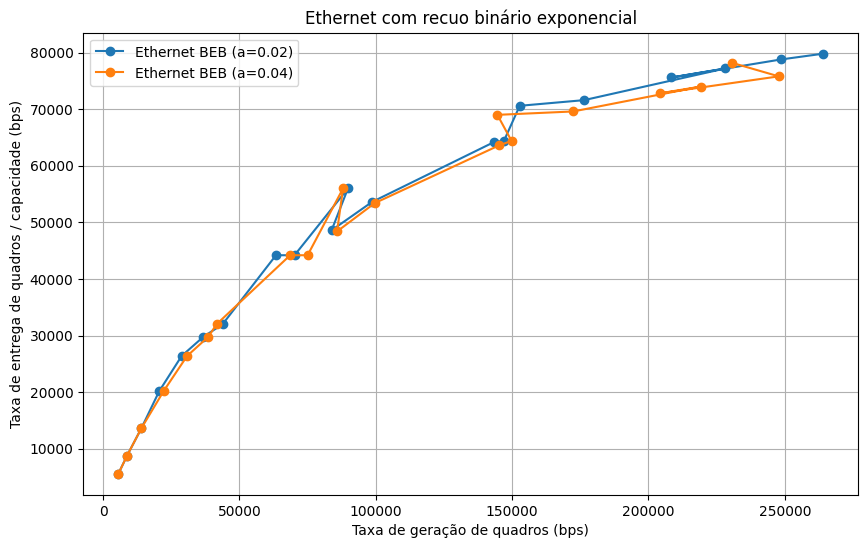

In [17]:
plt.figure(figsize=(10,6))

for a in [0.02, 0.04]:
    res = simula_ethernet_beb(
        tempo=0.1,
        n_est=10,
        taxa_bits=1e5,
        tam_quadro=100,
        a=a,
        rodadas=5,
        pontos=20,
        seed=42
    )

    plt.plot(
        res["carga_bps"],
        res["capacidade_bps"],
        'o-',
        label=f'Ethernet BEB (a={a})'
    )

plt.grid(True)
plt.xlabel('Taxa de geração de quadros (bps)')
plt.ylabel('Taxa de entrega de quadros / capacidade (bps)')
plt.title('Ethernet com recuo binário exponencial')
plt.legend()
plt.show()

In [18]:
def plota_variacao_parametro(nome_param, valores, fixos):
    plt.figure(figsize=(10,6))

    for valor in valores:
        params = fixos.copy()
        params[nome_param] = valor

        res = simula_ethernet_beb(
            tempo=params["tempo"],
            n_est=params["n_est"],
            taxa_bits=params["taxa_bits"],
            tam_quadro=params["tam_quadro"],
            a=params["a"],
            rodadas=params["rodadas"],
            pontos=params.get("pontos", 20),
            seed=42
        )

        plt.plot(res["carga_bps"], res["capacidade_bps"], 'o-', label=f'{nome_param}={valor}')

    plt.grid(True)
    plt.xlabel('Taxa de geração de quadros (bps)')
    plt.ylabel('Taxa de entrega de quadros / capacidade (bps)')
    plt.title(f'Influência de {nome_param} - Ethernet com BEB')
    plt.legend()
    plt.show()

In [20]:
param_base = {
    "tempo": 0.1,
    "n_est": 10,
    "taxa_bits": 1e5,
    "tam_quadro": 100,
    "a": 0.02,
    "rodadas": 5,
    "pontos": 20
}

##a) Tempo de simulação

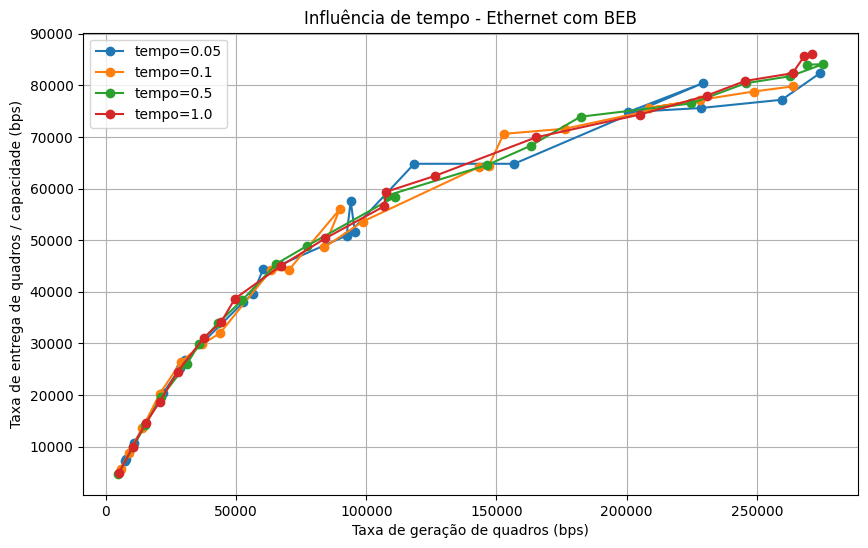

In [21]:
plota_variacao_parametro("tempo", [0.05, 0.1, 0.5, 1.0], param_base)

Quando o tempo de simulação é pequeno, os resultados apresentam maior flutuação estatística, pois há menos eventos observados. À medida que o tempo aumenta, a curva simulada fica mais regular e representativa do comportamento médio do sistema. No caso com BEB, esse efeito continua existindo, mas a estabilização tende a ser mais nítida porque o algoritmo reduz oscilações causadas por colisões sucessivas.

##b) Número de estações

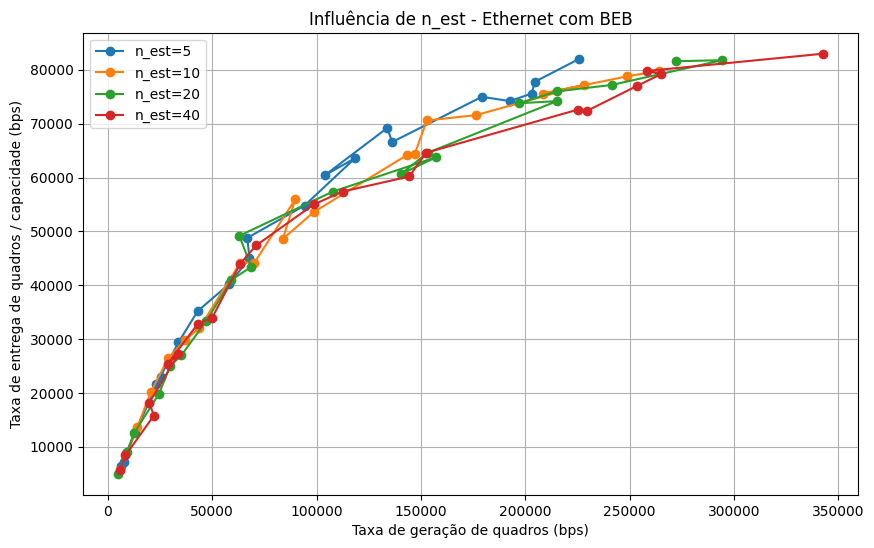

In [22]:
plota_variacao_parametro("n_est", [5, 10, 20, 40], param_base)

Com poucas estações, a probabilidade de colisão é menor e o desempenho se aproxima do limite máximo do meio. À medida que o número de estações cresce, a disputa pelo canal aumenta e o papel do backoff torna-se mais importante. O BEB melhora o comportamento em comparação com um recuo aleatório fixo, pois reduz a persistência de colisões repetidas. Mesmo assim, um número muito alto de estações ainda degrada a capacidade, pois há aumento da contenção e do tempo ocioso introduzido pelas esperas aleatórias.

##c) Taxa de transmissão

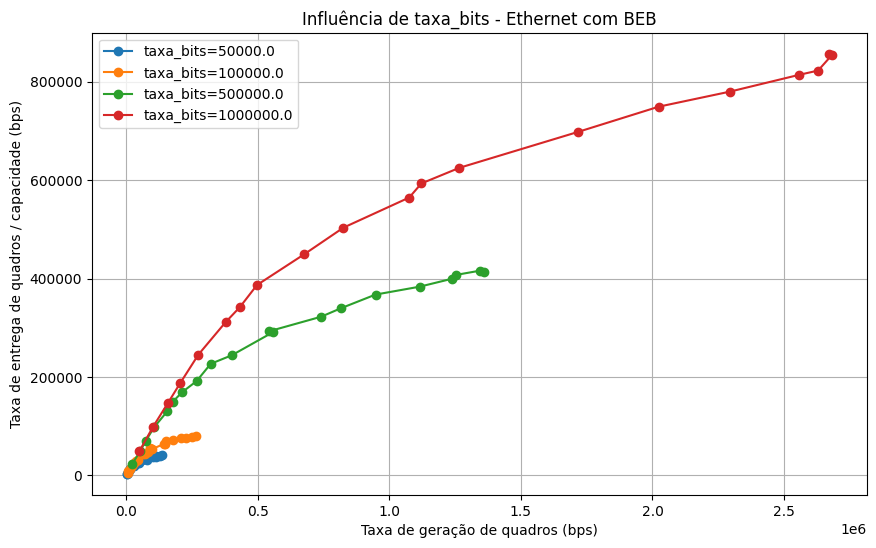

In [23]:
plota_variacao_parametro("taxa_bits", [5e4, 1e5, 5e5, 1e6], param_base)

Ao aumentar a taxa de transmissão em bps, o tempo de envio de cada quadro diminui, o que altera a relação entre transmissão e propagação. Se os demais parâmetros forem mantidos, o sistema pode transmitir mais bits por segundo, mas a eficiência relativa ainda depende do nível de contenção. O BEB ajuda a manter melhor desempenho em taxas mais altas quando há colisões, embora não elimine o efeito da competição pelo meio.

##d) Tamanho do quadro

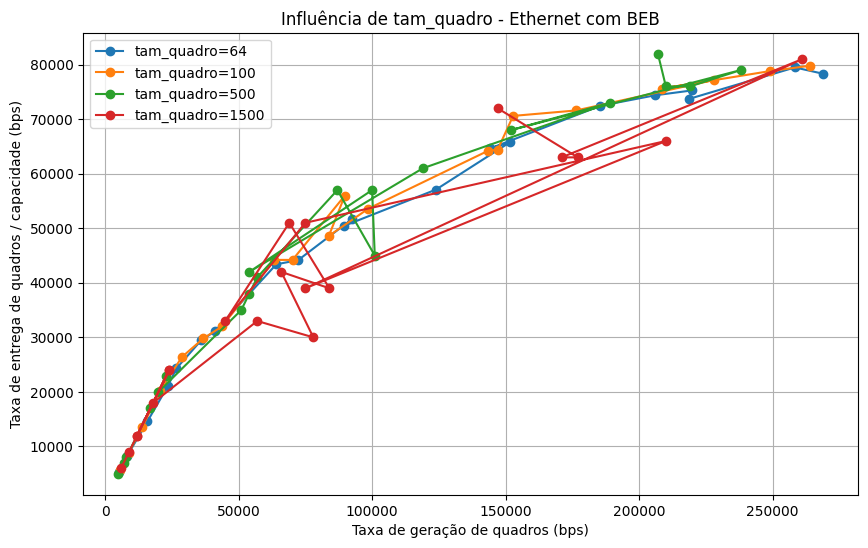

In [24]:
plota_variacao_parametro("tam_quadro", [64, 100, 500, 1500], param_base)

Quadros maiores tendem a melhorar a eficiência, porque a fração de tempo perdida com colisões e espera passa a representar uma parcela menor em relação ao tempo útil de transmissão. Com BEB, esse ganho permanece e costuma ser até mais perceptível em cargas elevadas, já que o protocolo consegue organizar melhor as retransmissões. Quadros muito pequenos, por outro lado, tornam o sistema mais sensível às colisões e ao atraso de propagação.


##e) Número de rodadas

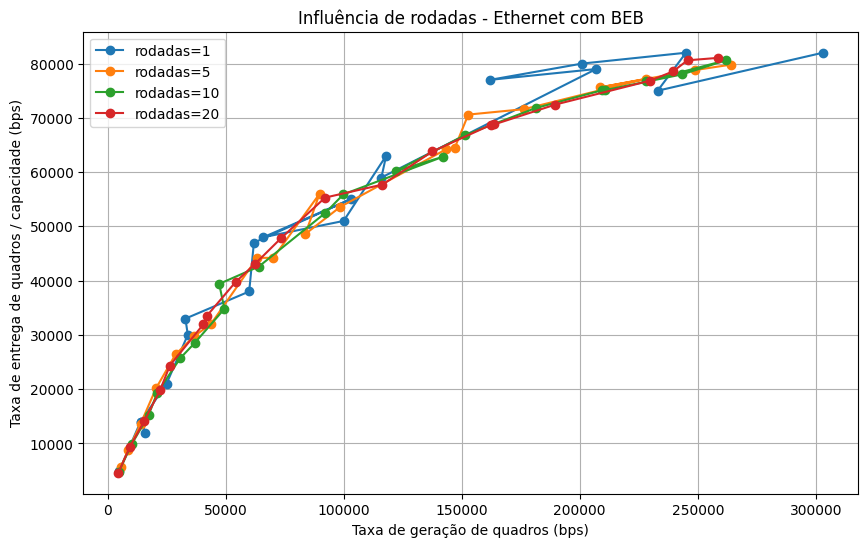

In [25]:
plota_variacao_parametro("rodadas", [1, 5, 10, 20], param_base)


O aumento do número de rodadas não altera o comportamento físico do protocolo, mas melhora a confiabilidade estatística dos resultados. Com mais rodadas, a média obtida se aproxima melhor do valor esperado e os gráficos ficam menos ruidosos. Isso é especialmente importante no caso com BEB, pois a escolha aleatória do tempo de recuo influencia diretamente os resultados instantâneos.

##f) Relação entre atraso de propagação e tempo de transmissão do quadro

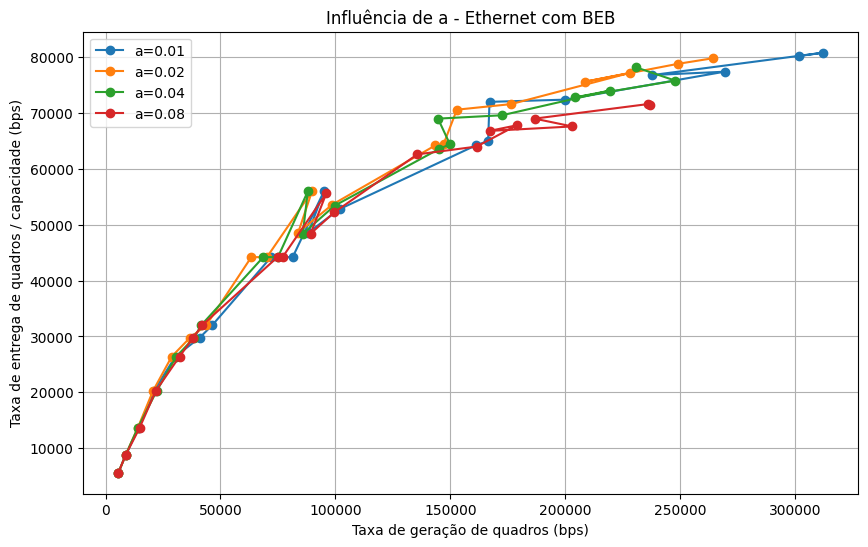

In [26]:
plota_variacao_parametro("a", [0.01, 0.02, 0.04, 0.08], param_base)



Esse é um dos parâmetros mais relevantes. Quanto maior o valor de a, maior o impacto do atraso de propagação em relação ao tempo de transmissão. Isso aumenta a chance de duas ou mais estações iniciarem transmissões quase simultâneas sem perceber imediatamente a ocupação do meio. O BEB reduz o efeito das colisões sucessivas, mas não elimina o problema fundamental de um a elevado. Portanto, conforme a aumenta, a capacidade do sistema tende a cair, embora a versão com Ethernet e recuo binário exponencial apresente comportamento melhor do que a versão sem esse mecanismo.

##Conclusão da etapa 4

A principal diferença observada com a inclusão do algoritmo Ethernet é que o sistema passa a reagir de forma mais eficiente às colisões, principalmente sob cargas elevadas. O recuo binário exponencial distribui melhor as retransmissões, reduz a repetição imediata de colisões e torna a curva de capacidade mais estável. Ainda assim, o desempenho continua sensível ao número de estações, ao tamanho do quadro e, principalmente, à relação entre atraso de propagação e tempo de transmissão. Em resumo, o BEB melhora a robustez da simulação em comparação com o caso anterior, mas não elimina as limitações naturais de um meio compartilhado.